<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
X=np.random.rand(100,1)-0.5
y=3*X[:,0]**2+0.05*np.random.rand(100)

In [ ]:
df=pd.DataFrame()

In [ ]:
df['X']=X.reshape(100)
df['y']=y

In [ ]:
df

,X,y
0,-0.125460,0.048792
1,0.450714,0.641251
2,0.231994,0.177181
3,0.098658,0.054629
4,-0.343981,0.400348
...,...,...
95,-0.006204,0.017576
96,0.022733,0.037848
97,-0.072459,0.060606
98,-0.474581,0.720035


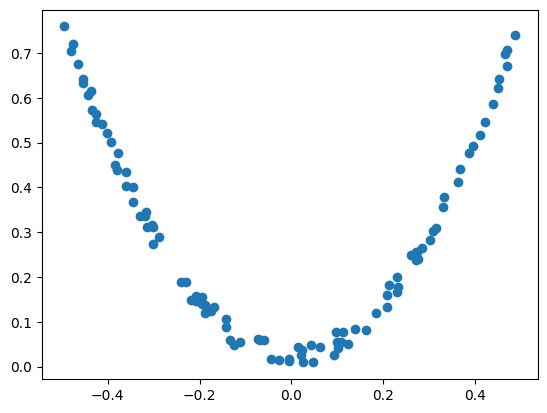

In [ ]:
plt.scatter(x=X,y=y)

In [ ]:
df['pred1']=df['y'].mean()

In [ ]:
df

,X,y,pred1
0,-0.125460,0.048792,0.290404
1,0.450714,0.641251,0.290404
2,0.231994,0.177181,0.290404
3,0.098658,0.054629,0.290404
4,-0.343981,0.400348,0.290404
...,...,...,...
95,-0.006204,0.017576,0.290404
96,0.022733,0.037848,0.290404
97,-0.072459,0.060606,0.290404
98,-0.474581,0.720035,0.290404


In [ ]:
df['res1']=df['y']-df['pred1']


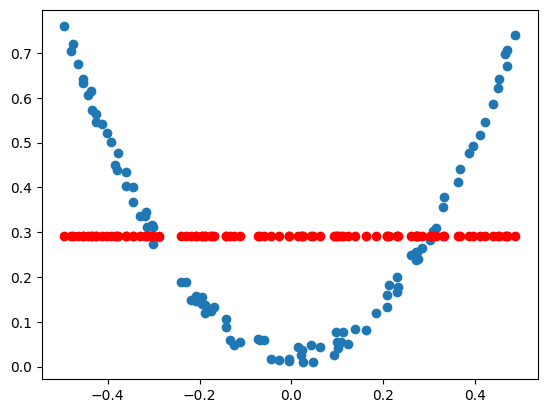

In [ ]:
plt.scatter(x=df['X'],y=df['y'])
plt.scatter(x=df['X'],y=df['pred1'],color='red')

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree1=DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
# generate test
X_test=np.linspace(-0.5,0.5,500)


In [ ]:
y_pred=0.290404+tree1.predict(X_test.reshape(500,1))

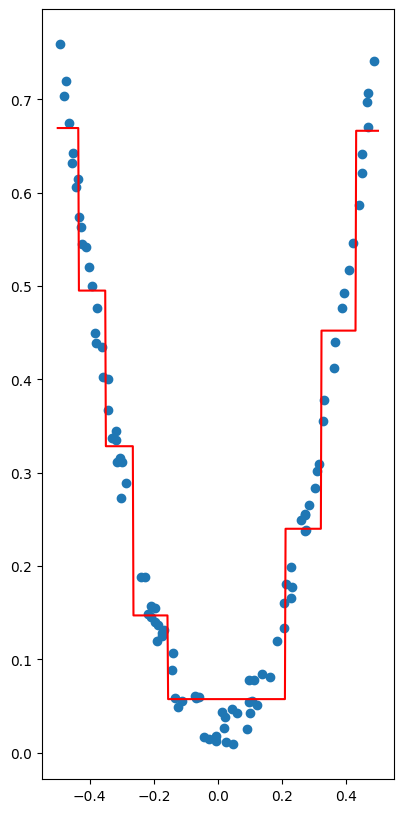

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.plot(X_test,y_pred,color='red')
plt.scatter(x=df['X'],y=df['y'])


In [ ]:
df['pred2']=290404+tree1.predict(df['X'].values.reshape(100,1))

In [ ]:
df

,X,y,pred1,res1,pred2
0,-0.125460,0.048792,0.290404,-0.241612,290403.767105
1,0.450714,0.641251,0.290404,0.350847,290404.376040
2,0.231994,0.177181,0.290404,-0.113223,290403.949627
3,0.098658,0.054629,0.290404,-0.235775,290403.767105
4,-0.343981,0.400348,0.290404,0.109944,290404.038074
...,...,...,...,...,...
95,-0.006204,0.017576,0.290404,-0.272828,290403.767105
96,0.022733,0.037848,0.290404,-0.252556,290403.767105
97,-0.072459,0.060606,0.290404,-0.229798,290403.767105
98,-0.474581,0.720035,0.290404,0.429631,290404.378985


In [ ]:
df['res2']=df['y']-df['pred2']

In [ ]:
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.048792,0.290404,-0.241612,290403.767105,-290403.718313
1,0.450714,0.641251,0.290404,0.350847,290404.376040,-290403.734789
2,0.231994,0.177181,0.290404,-0.113223,290403.949627,-290403.772445
3,0.098658,0.054629,0.290404,-0.235775,290403.767105,-290403.712476
4,-0.343981,0.400348,0.290404,0.109944,290404.038074,-290403.637726
...,...,...,...,...,...,...
95,-0.006204,0.017576,0.290404,-0.272828,290403.767105,-290403.749529
96,0.022733,0.037848,0.290404,-0.252556,290403.767105,-290403.729256
97,-0.072459,0.060606,0.290404,-0.229798,290403.767105,-290403.706498
98,-0.474581,0.720035,0.290404,0.429631,290404.378985,-290403.658950


In [ ]:
tree2=DecisionTreeRegressor(max_leaf_nodes=8)


In [ ]:
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
y_pred=290404 + sum(regressor.predict(X_test.reshape(-1,1)) for regressor in (tree1,tree2))

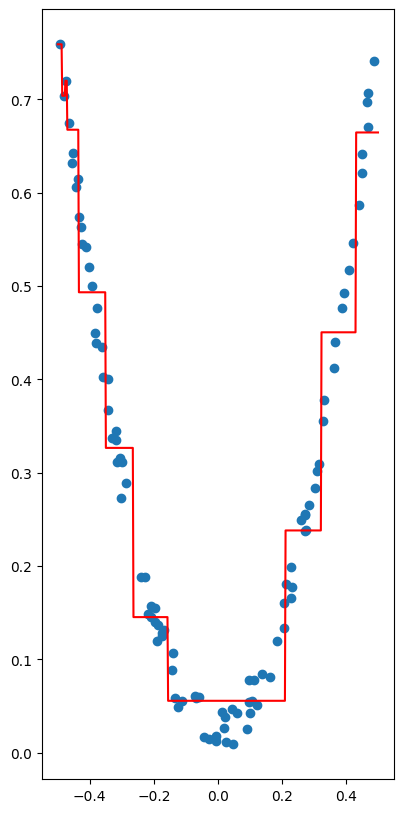

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.plot(X_test,y_pred,color='red')
plt.scatter(x=df['X'],y=df['y'])


In [ ]:
def gradient_boosting(X,y,number,learning_rate,max_leaf_nodes,count=1,regression=[],foo=None):
    if number == 0:
        return
    else:
      # do gradient boosting    #
      if count > 1:
        y=y-regression[-1].predict(X)
      else:
        foo=0
      tree_reg=DecisionTreeRegressor(max_depth=5,random_state=42)
      tree_reg.fit(X,y)
      regression.append(tree_reg)


      x1=np.linspace(-0.5,0.5,500)
      y_pred=sum(regressor.predict(x1.reshape(-1,1)) for regressor in regression)

      plt.figure(figsize=(10,10))
      plt.subplot(121)
      plt.plot(x1,y_pred,color='red')
      plt.scatter(x=df['X'],y=df['y'])

      print(number)
      gradient_boosting(X,y,number-1,learning_rate,max_leaf_nodes,count+1,regression,foo)

10
9
8
7
6
5
4
3
2
1


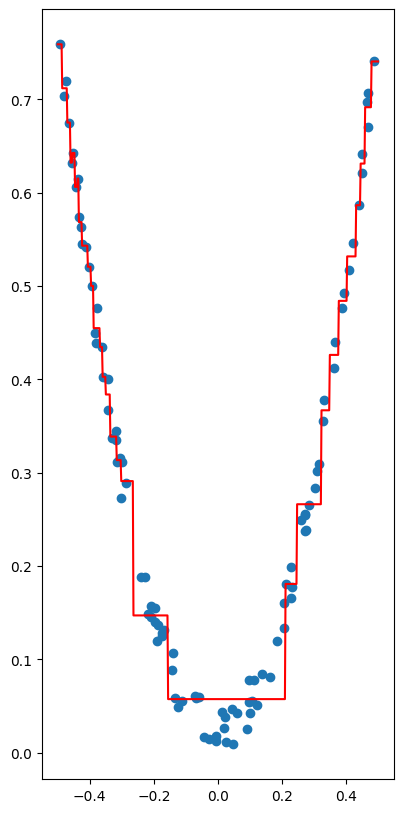

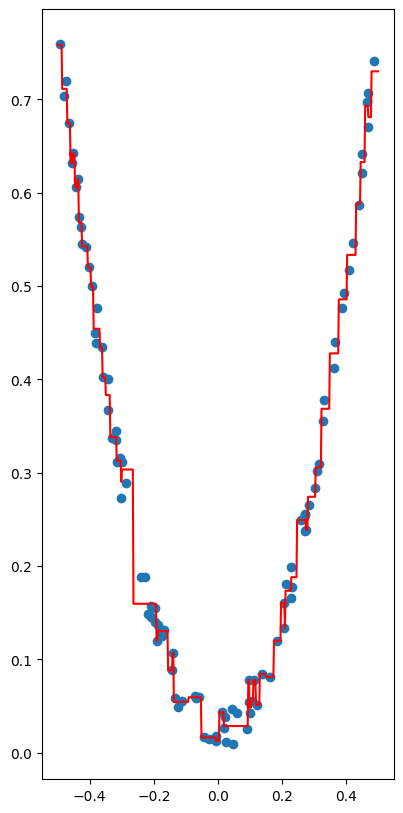

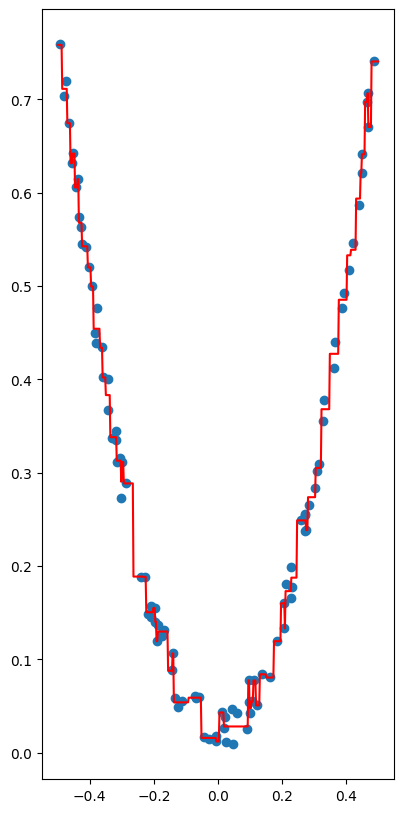

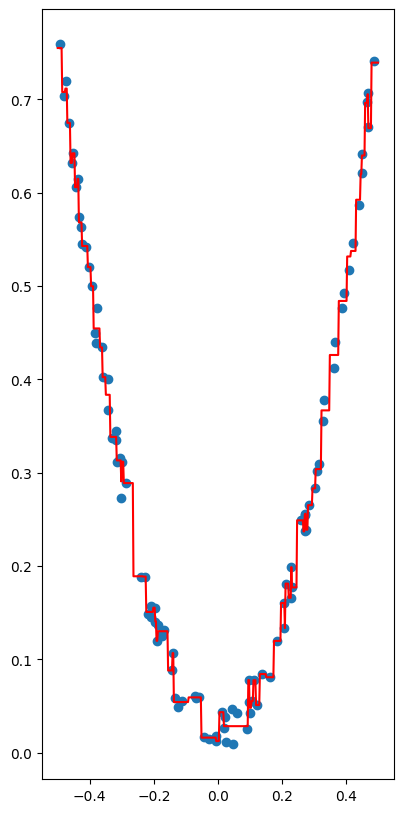

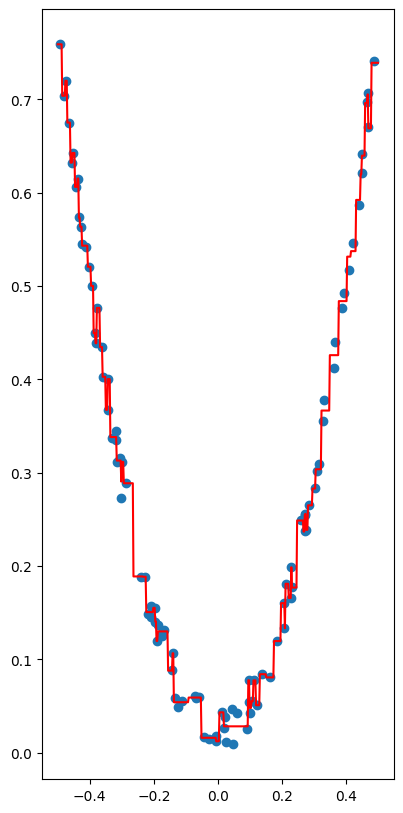

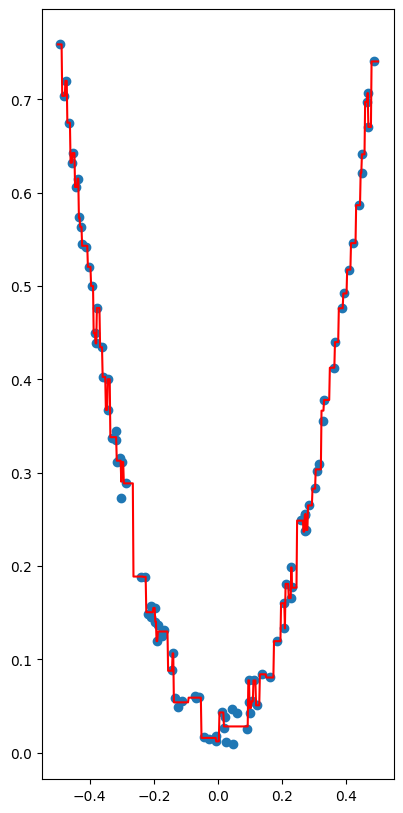

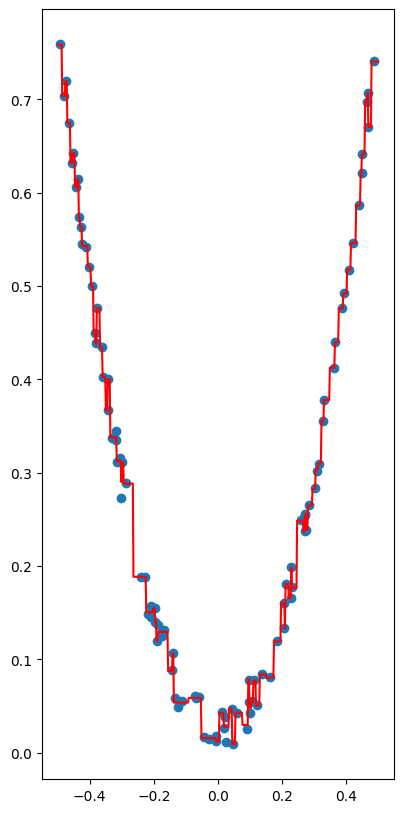

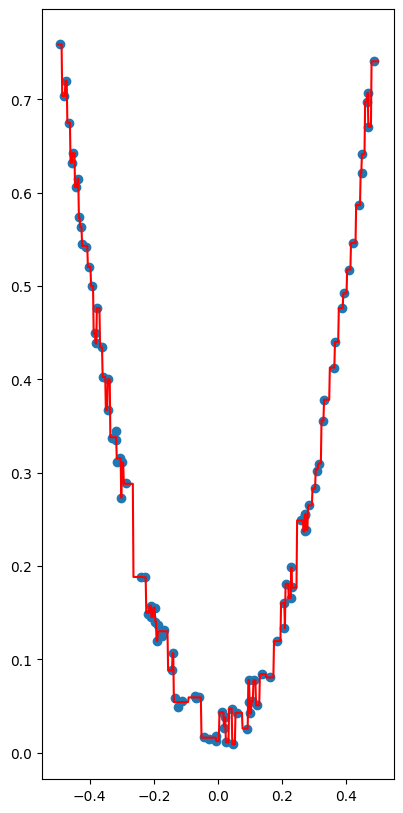

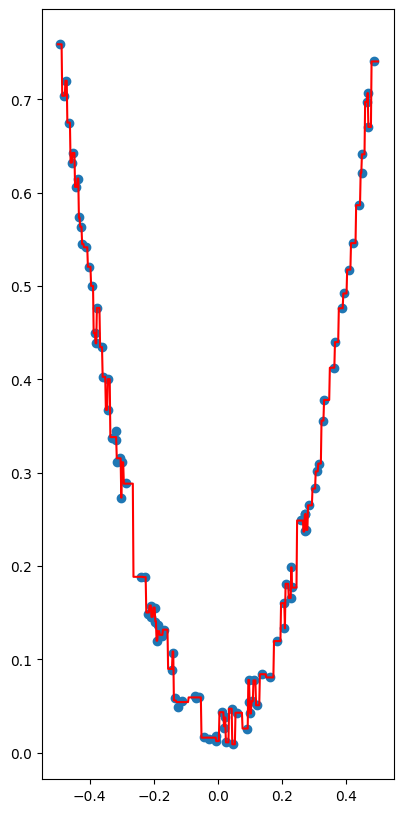

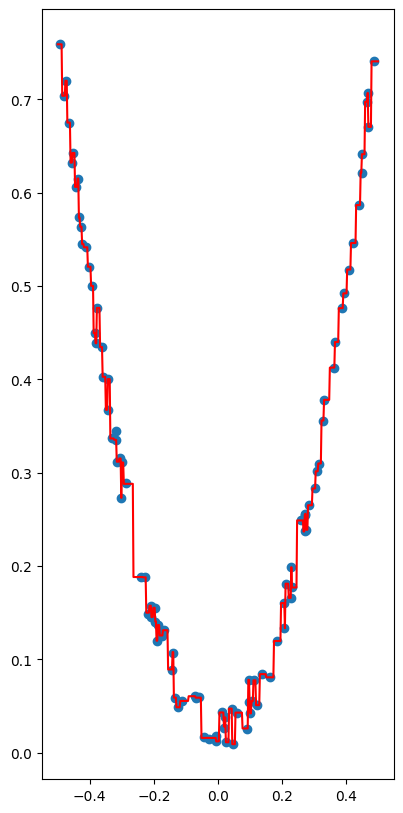

In [ ]:
np.random.seed(42)
X=np.random.rand(100,1)-0.5
y=3*X[:,0]**2+0.05*np.random.rand(100)
gradient_boosting(X,y,10,0.1,8)